In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from itertools import combinations
import sympy as sp

from ortools.linear_solver import pywraplp
from IPython.display import display, Markdown

def md(title, body):
    """
    계산 결과를 Markdown 형식으로 출력하는 보조함수.

    title : 해석 블록의 제목
    body  : 분석 결과에 대한 자연어 설명
    """
    
    display(
        Markdown(
            f"### {title}\n\n{body}"
        )
    )

STATUS_LABEL = {
    pywraplp.Solver.OPTIMAL: "OPTIMAL",
    pywraplp.Solver.FEASIBLE: "FEASIBLE",
    pywraplp.Solver.INFEASIBLE: "INFEASIBLE",
    pywraplp.Solver.UNBOUNDED: "UNBOUNDED",
    pywraplp.Solver.NOT_SOLVED: "NOT_SOLVED",
}


md(
    "환경 설정 완료",
    "이제부터 모든 결과를 **수식 → Solver → DataFrame → 자연어 해석** 순서로 확인한다."
)


plt.rcParams["axes.unicode_minus"] = False

HUMAN_CAP = 80
TOKEN_CAP = 100
PROFIT_TARGET = 210

print("STEP2 환경설정 완료")

### 환경 설정 완료

이제부터 모든 결과를 **수식 → Solver → DataFrame → 자연어 해석** 순서로 확인한다.

STEP2 환경설정 완료


# STEP 2 — Standard Form, Basis, Basic Feasible Solution

STEP 1에서는 다음 Human Business Model의 Feasibility를 확인했다.

이번에는 시각화를 위해 네 상품 중 두 개만 사용하는
2차원 Mini Model을 만든다.

$$
x = P0\text{ Product MVP 수}
$$

$$
y = P3\text{ Full Package 수}
$$

단, Simplex의 기하학을 공부하기 위해
이번 단계에서는 x와 y를 연속형 변수라고 가정한다.

$$
x,y\ge0
$$

---

## 상품별 값

| 항목 | P0 | P3 |
|---|---:|---:|
| 공헌이익 | 20 | 100 |
| Human Time | 6 | 28 |
| AI Token | 6 | 42 |

Token 단위는

$$
1U=10,000\text{ tokens}
$$

이다.

---

## 제약조건

### Human Capacity

$$
6x+28y\le80
$$

### AI Token Capacity

$$
6x+42y\le100
$$

### 최소 Profit 목표

$$
20x+100y\ge210
$$

### Non-negativity

$$
x,y\ge0
$$

---

## STEP 2의 질문

지금부터는 Solver가 답을 주는 것을 보는 것이 아니라,

1. 왜 부등식을 등식으로 바꾸는가?
2. Slack / Surplus는 무엇인가?
3. Artificial Variable은 왜 필요한가?
4. Basis란 무엇인가?
5. Basic Solution은 어떻게 계산하는가?
6. Basic Feasible Solution과 그래프의 꼭짓점은 왜 같은가?

를 직접 코드로 확인한다.

# 2-1. Slack Variable

첫 번째 제약조건은

$$
6x+28y\le80
$$

이다.

현재 x,y가 사용한 Human Time은

$$
6x+28y
$$

이고 전체 Capacity는 80이다.

따라서 남은 시간은

$$
80-(6x+28y)
$$

이다.

이 남은 양을 새로운 변수

$$
s_H\ge0
$$

로 정의한다.

그러면

$$
\boxed{
6x+28y+s_H=80
}
$$

이 된다.

즉 Slack Variable은

$$
\boxed{
s_H=\text{사용하지 않고 남은 자원}
}
$$

이다.

부등식을 등식으로 바꾸었지만
원래 문제의 의미는 변하지 않았다.

In [45]:
x_sample = 1
#productMVP를 1건으로 가정

y_sample = 2
#fullPACKAGE를 2건이라 가정

human_used = (
    6 * x_sample 
    + 28 * y_sample
)
#실제 사용 human time계산

human_slack = (
    HUMAN_CAP 
    - human_used
)
#전체 capa에서 human used 즉 80에서 실 사용시간을 뺀다

print("P0 =", x_sample)
print("P3 =", y_sample)

print("사용 human time = ", human_used)
print("human slack", human_slack)

#등식이 정말 성립하는지도 확인

left_side = (
    6 * x_sample
    + 28 * y_sample
    + human_slack 
)

print("6x + 28y + s_H =", left_side)
print("Right-hand side =", HUMAN_CAP)

P0 = 1
P3 = 2
사용 human time =  62
human slack 18
6x + 28y + s_H = 80
Right-hand side = 80


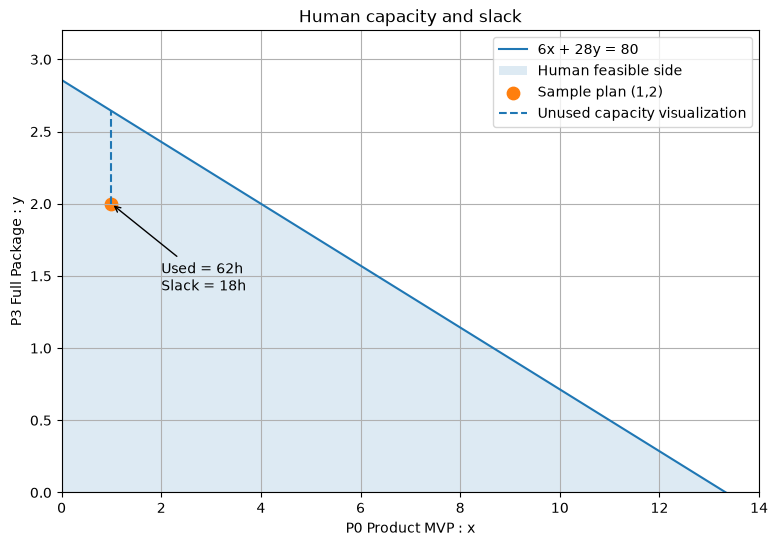

In [46]:
#Human Constraint와 Slack 시각화


# x축에서 P0 프로젝트 수를 0~14까지 연속적으로 만든다.
x_grid = np.linspace(0, 14, 400)


# 경계식:
#
# 6x + 28y = 80
#
# 를 y에 대해 풀면
#
# y = (80 - 6x) / 28

human_boundary = (
    HUMAN_CAP
    - 6 * x_grid
) / 28


# y가 음수가 되는 부분은
# 현실적인 non-negative 영역 밖이므로
# 그림에서는 0 이상인 부분만 사용한다.
human_boundary_positive = np.maximum(
    human_boundary,
    0
)


plt.figure(figsize=(9, 6))


# Human Capacity의 경계선을 그린다.
plt.plot(
    x_grid,
    human_boundary,
    label="6x + 28y = 80"
)


# 경계선 아래가
# 6x + 28y <= 80
# 을 만족하는 영역이다.
plt.fill_between(
    x_grid,
    0,
    human_boundary_positive,
    alpha=0.15,
    label="Human feasible side"
)


# 우리가 선택한 점 (1,2)를 표시한다.
plt.scatter(
    x_sample,
    y_sample,
    s=80,
    label="Sample plan (1,2)"
)


# x=1일 때 Human Capacity 경계선의 y값을 계산한다.
y_on_human_boundary = (
    HUMAN_CAP
    - 6 * x_sample
) / 28


# 현재 점에서 경계까지 수직선을 그린다.
plt.vlines(
    x_sample,
    y_sample,
    y_on_human_boundary,
    linestyles="--",
    label="Unused capacity visualization"
)


# 현재 점의 위치를 텍스트로 표시한다.
plt.annotate(
    f"Used = {human_used}h\nSlack = {human_slack}h",
    xy=(x_sample, y_sample),
    xytext=(2.0, 1.4),
    arrowprops={"arrowstyle": "->"}
)


plt.xlabel("P0 Product MVP : x")
plt.ylabel("P3 Full Package : y")

plt.title("Human capacity and slack")

plt.xlim(0, 14)
plt.ylim(0, 3.2)

plt.grid(True)
plt.legend()
plt.show()

여기서 주의.

그림에서 점과 선 사이의 수직거리 자체가 18시간인 것은 아니다.

수직 gap은:

$$ \Delta y = \frac{18}{28} $$

이다.

왜냐하면 P3 한 단위 증가가 Human Time을 28시간 사용하기 때문이다.

즉:

$$ 28\Delta y=s_H. $$

이 distinction을 잡아야 한다

# 2-2. Surplus Variable

이번에는 Profit 목표를 보자.

$$
20x+100y\ge210
$$

이 경우에는 목표보다 많이 벌 수 있다.

실제 Profit이 210보다 얼마나 초과했는지를

$$
s_P\ge0
$$

라고 정의한다.

그러면

$$
\boxed{
20x+100y-s_P=210
}
$$

이다.

왜 더하는 것이 아니라 빼는가?

실제 Profit이 220이라면

$$
220-s_P=210
$$

이어야 하므로

$$
s_P=10
$$

이어야 하기 때문이다.

따라서

$$
\boxed{
s_P=\text{목표를 초과한 양}
}
$$

이다.

Slack과 Surplus는 방향이 다르다.

$$
\le \quad\Rightarrow\quad +Slack
$$

$$
\ge \quad\Rightarrow\quad -Surplus
$$

Actual Profit = 220
Profit Target = 210
Profit Surplus = 10


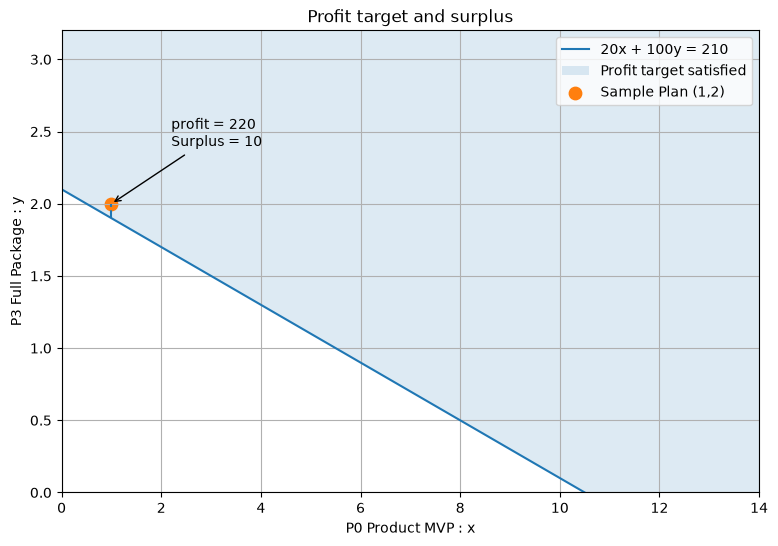

In [47]:
profit_actual = (
    20 * x_sample
    + 100 * y_sample
)
# x,y = 1,2 의 실제 profit

profit_surplus = (
    profit_actual
    - PROFIT_TARGET
)
#목표보다 즉 210보다 얼마나 벌었는지.

print("Actual Profit =", profit_actual)
print("Profit Target =", PROFIT_TARGET)
print("Profit Surplus =", profit_surplus)

# Profit 목표 경계선 시각화
# -------------------------------------------

profit_boundary = (
    PROFIT_TARGET
    - 20 * x_grid
) / 100
# 20x + 100y = 210에 대해서 y에 대해 푼것.

plt.figure(figsize=(9,6))
plt.plot(
    x_grid,
    profit_boundary,
    label="20x + 100y = 210"
)
#profit은 >= 210이므로 경계선 위쪽이 목표를 만족하는 영역이다.

plt.fill_between(
    x_grid,
    np.maximum(profit_boundary, 0),
    3.2,
    alpha=0.15,
    label="Profit target satisfied"
)

plt.scatter(
    x_sample,
    y_sample,
    s=80,
    label="Sample Plan (1,2)"
)

#x=1에서 목표 pfofit을 210을 정확히 만드는 y값
y_on_human_boundary = (
    PROFIT_TARGET
    - 20 * x_sample
) / 100

plt.vlines(
    x_sample,
    y_on_human_boundary,
    y_sample,
    linestyles="--"

)

plt.annotate(
    f"profit = {profit_actual}\nSurplus = {profit_surplus}",
    xy=(x_sample, y_sample),
    xytext=(2.2, 2.4),
    arrowprops={"arrowstyle": "->"}
)


plt.xlabel("P0 Product MVP : x")
plt.ylabel("P3 Full Package : y")

plt.title("Profit target and surplus")

plt.xlim(0, 14)
plt.ylim(0, 3.2)

plt.grid(True)
plt.legend()
plt.show()

# 왜 Artificial Variable이 필요한가?

# 2-3. Artificial Variable

Profit 제약은

$$
20x+100y\ge210
$$

이었다.

Surplus를 빼서

$$
20x+100y-s_P=210
$$

으로 만들었다.

그런데 Simplex의 출발점으로

$$
x=0,\qquad y=0
$$

을 생각해보자.

그러면

$$
-s_P=210
$$

이다.

따라서

$$
s_P=-210
$$

이 필요한데,

$$
s_P\ge0
$$

이어야 하므로 불가능하다.

즉 단순히 Surplus Variable만 넣어서는
초기 Basic Feasible Solution을 만들기 어렵다.

그래서 계산을 시작하기 위한 임시 변수

$$
a_P\ge0
$$

를 추가한다.

$$
\boxed{
20x+100y-s_P+a_P=210
}
$$

이제 x=y=s_P=0이라고 하면

$$
a_P=210
$$

으로 등식을 만족시킬 수 있다.

---

## Artificial Variable의 의미

Artificial Variable은 현실의 자원이 아니다.

돈도 아니다.
시간도 아니다.
프로젝트도 아니다.

Simplex가 출발할 수 있도록
임시 Basis column을 만드는 계산용 변수다.

따라서 최종적으로는 반드시

$$
\boxed{a_P=0}
$$

으로 제거되어야 한다.

Phase I에서는

$$
\min a_P
$$

를 수행한다.

최솟값이 0이면 원래 문제가 feasible하다.

0보다 크게 남으면 원래 문제에는 feasible solution이 없다.

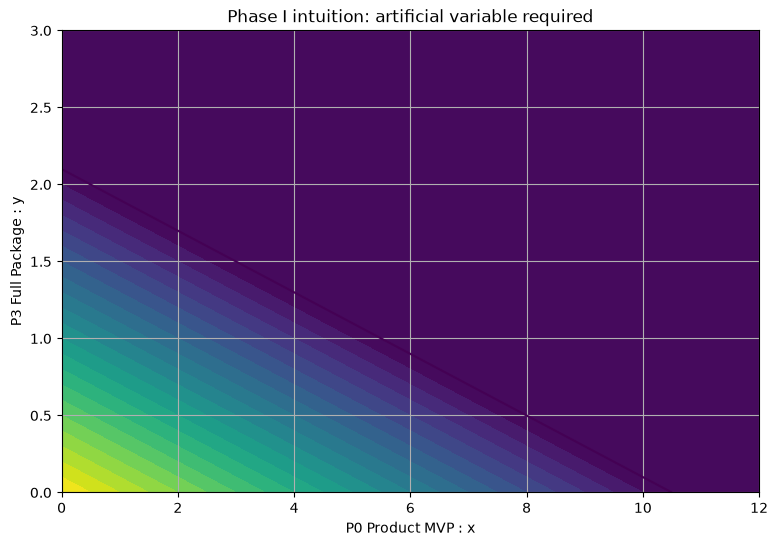

### Profit이 낮은 영역: $$ a_P>0. $$, Profit target을 넘어가면: $$ a_P=0. $$

즉 Phase I은 일종의 “Artificial 높이가 0인 원래 feasible 공간까지 내려가는 과정”으로 볼 수 있다.

None


In [48]:
# 각 (x,y)에서 필요한 최소 Artificial Variable 계산


# 2차원 grid를 만든다.
x_values = np.linspace(0, 12, 200)
y_values = np.linspace(0, 3, 200)

X, Y = np.meshgrid(
    x_values,
    y_values
)
# X, Y 모든 (X,Y) 조합이 GRID 형태로 저장될 수 있도록한다.

profit_grid = (
    20 * X
    + 100 * Y
)
# GRID의 모든 점에서 PROFIT을 계산한다.

artificial_required = np.maximum(
    0, 
    PROFIT_TARGET - profit_grid
)
# profit이 210보다 작으면, 부족한만큼 artificial variable이 필요한데, profit >= 210일시 => artificial은 0이면 된다.

plt.figure(figsize=(9, 6))

#artificial variable은 0이면 된다.
contour = plt.contourf(
    X,
    Y,
    artificial_required,
    levels=20
)

# 이때 오른쪽 colorbar는 각 위치에서 필요한 a_p의 크기를 나타낼 수 있도록한다.
plt.contour(
    X,
    Y,
    profit_grid,
    levels=[PROFIT_TARGET]
)
plt.xlabel("P0 Product MVP : x")
plt.ylabel("P3 Full Package : y")

plt.title("Phase I intuition: artificial variable required")

plt.grid(True)
plt.show()

print(md("Profit이 낮은 영역: $$ a_P>0. $$, Profit target을 넘어가면: $$ a_P=0. $$", "즉 Phase I은 일종의 “Artificial 높이가 0인 원래 feasible 공간까지 내려가는 과정”으로 볼 수 있다."))


# 2-4. Standard Form

현재 세 식은 다음과 같다.

Human:

$$
6x+28y+s_H=80
$$

Token:

$$
6x+42y+s_T=100
$$

Profit:

$$
20x+100y-s_P+a_P=210
$$

변수들을 하나의 Vector로 묶자.

$$
z=
\begin{bmatrix}
x\\
y\\
s_H\\
s_T\\
s_P\\
a_P
\end{bmatrix}
$$

그러면 전체 시스템은

$$
\boxed{Az=b}
$$

로 쓸 수 있다.

여기서

$$
A=
\begin{bmatrix}
6&28&1&0&0&0\\
6&42&0&1&0&0\\
20&100&0&0&-1&1
\end{bmatrix}
$$

이고

$$
b=
\begin{bmatrix}
80\\
100\\
210
\end{bmatrix}
$$

이다.

이 순간부터 matrix와 OR 문제가 완전히 합쳐진다.

Source의 표현대로:

$$ Az = z_1A_1+z_2A_2+\cdots+z_6A_6. $$

즉 A의 column들을 변수 값만큼 섞어서 \(b\)를 만드는 문제다.

$$
z=
\begin{bmatrix}
x\\
y\\
s_H\\
s_T\\
s_P\\
a_P
\end{bmatrix}
=
A=
\begin{bmatrix}
6&28&1&0&0&0\\
6&42&0&1&0&0\\
20&100&0&0&-1&1
\end{bmatrix}
$$


$$
Z
\begin{bmatrix}
x\\
y\\
s_H\\
s_T\\
s_P\\
a_P
\end{bmatrix}
A
\begin{bmatrix}
6&28&1&0&0&0\\
6&42&0&1&0&0\\
20&100&0&0&-1&1
\end{bmatrix}
=
B
\begin{bmatrix}
80\\
100\\
210
\end{bmatrix}
$$

In [52]:

variable_names = [
    "x_P0",
    "y_P3",
    "s_H",
    "s_T",
    "s_P",
    "a_P",
]
# A의 각 COLUMN이 의미하는 변수를 순서대로 저장한다

constraint_names = [
    "Human",
    "Token",
    "Profit",
] #A의 각 row가 의미하는 constraints

A = np.array(
    [
        [6, 28, 1, 0, 0, 0],
        [6, 42, 0, 1, 0, 0],
        [20, 100, 0, 0, -1, 1],
    ],
    dtype=float,
) # coefficient matrix A.

b = np.array(
    [
        80,
        100,
        210,
    ],
    dtype=float,
)#right-hand 우변 벡터 b

A_df = pd.DataFrame(
    A,
    index=constraint_names,
    columns=variable_names,
)

b_df = pd.DataFrame(
    {
        "b": b
    },
    index=constraint_names,
)
display(A_df)
display(b_df)

print("A shape =", A.shape)
print("b shape =", b.shape)
print("rank(A) =", np.linalg.matrix_rank(A))

print(md("여기서: $$ A.shape=(3,6) $$이다.", "즉 3개의 equation과 6개의 variable 그리고 rank는 3이다."))

,x_P0,y_P3,s_H,s_T,s_P,a_P
Human,6.0,28.0,1.0,0.0,0.0,0.0
Token,6.0,42.0,0.0,1.0,0.0,0.0
Profit,20.0,100.0,0.0,0.0,-1.0,1.0


,b
Human,80.0
Token,100.0
Profit,210.0


A shape = (3, 6)
b shape = (3,)
rank(A) = 3


### 여기서: $$ A.shape=(3,6) $$이다.

즉 3개의 equation과 6개의 variable 그리고 rank는 3이다.

None


# 행이 3개인데 왜 Basis도 3개인가

# 2-5. Basis

A에는 6개의 Column Vector가 있다.

$$
A=
[A_x,A_y,A_{s_H},A_{s_T},A_{s_P},A_{a_P}]
$$

각 column은 세 개의 component를 가지므로

$$
A_j\in\mathbb R^3
$$

이다.

현재 독립 constraint의 수는

$$
rank(A)=3
$$

이다.

따라서 하나의 Basis는
A의 column들 중

$$
\boxed{3개의 선형독립 column}
$$

을 선택해서 만든다.

선택한 세 column을 모은 행렬을

$$
B
$$

라고 한다.

그러면 Basic Variable만 남겨

$$
Bx_B=b
$$

를 푼다.

나머지 Nonbasic Variable은 0으로 둔다.

따라서

$$
\boxed{x_B=B^{-1}b}
$$

가 된다.

## 여기서 “basis”는 그냥 중요한 변수들이 아니다.

column space에서 \(b\)를 표현할 좌표축 역할을 하는 독립 column 집합이다.

In [54]:
# 초기 basis = {s_h, s_t, a_p}

initial_basis_names = [
    "s_H",
    "s_T",
    "a_P",
] # 초기에는 두 slack과 Artificial Variables를 Basic Variables로 사용한다.

initial_basis_idx = [
    variable_names.index(name)
    for name in initial_basis_names
] # 변수 이름을 실제 A의 column index로 변환한다.